# Homework 3: Neural Machine Translation with Attention

## 1. Introduction

Neural machine translation (NMT) is the task of automatically translating text from one language to another using neural networks. In this assignment, we work with a German-to-English translation system based on the [sequence-to-sequence (seq2seq)](https://arxiv.org/abs/1409.3215) architecture with an encoder-decoder framework.

The key challenge in this assignment is fixing the broken attention mechanism. The provided pre-trained model has a non-functional attention module that produces uniform weights, resulting in poor translations (BLEU score of 1.86). Without proper attention, the decoder cannot focus on relevant source words when generating each target word.

Our baseline implements the [additive attention mechanism](https://arxiv.org/abs/1409.0473) (Bahdanau attention) to allow the decoder to dynamically focus on different parts of the source sentence. We improved this baseline through one major modification:

1. **Beam search decoding** to explore multiple translation candidates instead of greedily selecting the best word at each step

## 2. Method

### 2.1 Baseline Architecture

The seq2seq model consists of three components:

- **Encoder**: A bidirectional GRU that processes the German input sentence and produces hidden states $h_i^{enc}$ for each source word
- **Attention**: Computes attention weights to determine which source words to focus on
- **Decoder**: A GRU that generates English words one at a time using the attention-weighted context

The broken attention module simply returns uniform weights (all equal), causing the decoder to average all encoder states equally regardless of relevance. This results in a context vector that contains no useful alignment information.

### 2.2 Improvement 1: Additive Attention Mechanism

We implemented additive attention following [Bahdanau et al. (2015)](https://arxiv.org/abs/1409.0473). The attention mechanism computes relevance scores between the current decoder state and each encoder hidden state:

$$\text{score}_i = W_{enc}(h_i^{enc}) + W_{dec}(h^{dec})$$

$$\alpha = \text{softmax}(V \cdot \tanh(\text{score}))$$

$$c = \sum_i \alpha_i \times h_i^{enc}$$

Where:
- $h_i^{enc}$ is the encoder hidden state for source word $i$
- $h^{dec}$ is the current decoder hidden state
- $W_{enc}$, $W_{dec}$, $V$ are learned weight matrices
- $\alpha$ is the attention weights (probabilities summing to 1)
- $c$ is the context vector (weighted sum of encoder states)

The implementation in `calcAlpha` computes attention weights:

```python
def calcAlpha(self, decoder_hidden, encoder_out):
    # Additive attention: compute relevance scores
    enc_proj = self.W_enc(encoder_out)      # Project encoder states
    dec_proj = self.W_dec(decoder_hidden)   # Project decoder state
    score = torch.tanh(enc_proj + dec_proj) # Combine with tanh
    score = self.V_att(score)               # Reduce to scalar
    alpha = F.softmax(score, dim=0)         # Normalize to weights
    return alpha
```

The `forward` function computes the context vector as a weighted sum:

```python
def forward(self, decoder_hidden, encoder_out):
    # Compute context as weighted sum of encoder states
    alpha = self.calcAlpha(decoder_hidden, encoder_out)
    context = torch.sum(alpha * encoder_out, dim=0)
    context = context.unsqueeze(0)
    # Reshape alpha for output
    alpha = alpha.squeeze(2).permute(1, 0).unsqueeze(0)
    return context, alpha
```

### 2.3 Improvement 2: Beam Search Decoding

The baseline uses **greedy decoding**, which always selects the highest probability word at each step. This can lead to suboptimal translations because the locally best choice may not lead to the globally best sequence.

We implemented **beam search** to explore multiple translation candidates simultaneously. At each decoding step, beam search maintains the top-$k$ most promising partial translations (beams) rather than committing to a single choice.

| Decoding | Strategy | Example |
|:---|:---|:---|
| **Greedy** | Always pick best word | "The" → "cat" → "sat" (might miss better paths) |
| **Beam Search** | Keep top-k candidates | Explores ["The cat", "A cat", "The dog"] simultaneously |

The beam search algorithm:

1. Initialize with the start token `<sos>`
2. At each step, expand each beam with the top-$k$ possible next words
3. Keep only the top-$k$ sequences by cumulative log probability
4. Stop when `<eos>` is generated or maximum length is reached
5. Return the highest-scoring complete sequence with **length normalization**

Length normalization (dividing score by sequence length) prevents the model from favoring shorter sequences, which naturally have higher probabilities.

```python
def beamSearchDecoder(decoder, encoder_out, encoder_hidden, maxLen, beam_width=5):
    # Initialize beams: (score, token_sequence, hidden_state)
    beams = [(0.0, [hp.sos_idx], decoder_hidden)]
    completed = []
    
    for t in range(maxLen):
        all_candidates = []
        for score, seq, hidden in beams:
            if seq[-1] == hp.eos_idx:
                completed.append((score, seq, hidden))
                continue
            
            # Decode one step
            output, new_hidden, alpha = decoder(last_token, encoder_out, hidden)
            log_probs = log_softmax(output)
            topk_probs, topk_indices = log_probs.topk(beam_width)
            
            # Expand with top-k candidates
            for i in range(beam_width):
                new_score = score + topk_probs[i].item()
                new_seq = seq + [topk_indices[i].item()]
                all_candidates.append((new_score, new_seq, new_hidden))
        
        # Keep top beam_width candidates
        beams = sorted(all_candidates, reverse=True)[:beam_width]
    
    # Return best with length normalization
    completed.sort(key=lambda x: x[0] / len(x[1]), reverse=True)
    return completed[0]
```

We use `beam_width=5` as it provides a good balance between translation quality and computational efficiency.

## 3. Experiments and Results

### 3.1 Experimental Setup

All experiments are evaluated on `data/input/dev.txt` using the BLEU score metric. BLEU (Bilingual Evaluation Understudy) measures the similarity between machine-generated translations and reference translations based on n-gram overlap.

We tested two configurations:
- **Baseline**: Fixed attention mechanism with greedy decoding
- **Beam Search**: Fixed attention mechanism with beam search decoding (beam_width=5)

### 3.2 Overall Results

| Exp | Attention | Decoding | BLEU Score | ΔBLEU |
|:---:|:---:|:---|:---:|:---:|
| Default | Broken (uniform) | Greedy | 1.86 | — |
| Baseline | Fixed (additive) | Greedy | 14.24 | +12.38 |
| **Best** | **Fixed (additive)** | **Beam Search (k=5)** | **16.39** | **+14.53** |

## 4. Analysis

We analyse the outputs of all three systems at the sentence level to understand where and why each improvement helps. Per-sentence BLEU scores are computed with SacreBLEU (`smooth_method='exp'`). The three hypothesis files were scored against the reference and source using `analysis.py`, producing one CSV per system with columns: `id`, `src_len` (German word count), `source`, `reference`, `hypothesis`, `bleu`. The CSVs are then merged on `id` so every row holds all three system outputs for the same sentence, making it straightforward to compare systems directly.

### 4.1 Effect of Fixing Attention

To isolate the contribution of the attention fix, we compare the *default* system (broken uniform attention + greedy decoding) against the *baseline* (fixed additive attention + greedy decoding). For each sentence we compute:

$$\Delta_{\text{attn}} = \text{BLEU}_{\text{greedy}} - \text{BLEU}_{\text{default}}$$

We select the four sentences with the largest $\Delta_{\text{attn}}$ among sentences with at most 20 German words (so examples are readable) where the greedy output is already decent (BLEU > 25), giving clear before/after comparisons.

**Selected Examples**

| # | German Source | Reference | Default (broken) | Greedy (fixed attn) | $\Delta_{\text{attn}}$ |
|:---|:---|:---|:---|:---|:---:|
| 1043 | Es gibt keine Vorbilder für sie . | There 's no models for them . | you have . `[7.3]` | there 's no models for them . `[80.9]` | **+73.7** |
| 313 | Das ist etwas aus einem Roman . | This is something from a novel . | something is something . `[16.7]` | this is something from a novel . `[80.9]` | **+64.2** |
| 177 | Aber das ist so ungerecht . | But that 's so unfair . | so 's that . `[13.7]` | but that 's so unfair . `[76.0]` | **+62.3** |
| 474 | Jetzt kann ich auch auf dem Kopf stehen . | And now I can stand on my head . | i can go on . `[6.3]` | now i can stand on my head . `[62.4]` | **+56.1** |

All four examples are short, simple sentences (6–9 German words) where the meaning maps almost word-for-word between German and English. Despite this simplicity, the broken attention produces completely wrong output, because the context vector is a meaningless uniform average of all encoder states, carrying no positional information. The decoder has no way to know which source word corresponds to the current generation step, so it falls back on the most frequent patterns it has seen.

### 4.2 Effect of Beam Search

To isolate the contribution of beam search, we compare the *baseline* (fixed attention + greedy decoding) against our *best* system (fixed attention + beam search, $k=5$). For each sentence:

$$\Delta_{\text{beam}} = \text{BLEU}_{\text{beam}} - \text{BLEU}_{\text{greedy}}$$

We select the four sentences with the largest $\Delta_{\text{beam}}$ among sentences where beam search produces a decent translation (BLEU > 30) and the sentence is at least 5 words long.

**Selected Examples:**

| # | German Source | Reference | Greedy | Beam Search ($k=5$) | $\Delta_{\text{beam}}$ |
|:---|:---|:---|:---|:---|:---:|
| 1161 | Man kann jungen Leuten beibringen , Unternehmer zu sein . | And you can train young people to be entrepreneurs . | you can be young people to entrepreneurs **entrepreneurs** . `[24.1]` | you can be young people to be entrepreneurs . `[59.1]` | **+35.0** |
| 666 | Und das war der Anfang einer sehr seltsamen Reise für mich . | And that was the beginning of a very strange journey for me . | and that was the very strange journey . `[19.2]` | and that was the very strange journey **for me** . `[48.8]` | **+29.5** |
| 1250 | Daraus wird ein " Mund " . | You get a mouth . | it 's called . . `[10.7]` | it becomes **a mouth** . `[39.8]` | **+29.1** |
| 1197 | Ich fing an , Formen zu sehen , und Muster , die mir halfen , sie zu sammeln . | I started seeing shapes and patterns that helped me to collect them . | i began to see forms and patterns that **me me** . `[13.8]` | i began to see shapes and patterns that helped me me . `[41.2]` | **+27.4** |

The four examples reveal two distinct failure modes of greedy decoding that beam search corrects:

1. **Word repetition** (sentence #1161): greedy outputs *"entrepreneurs entrepreneurs"* — once the decoder generates a high-probability word, it can get stuck repeating it because the greedy path never explores alternatives. Beam search keeps five candidate sequences alive simultaneously; the path that correctly inserts *"to be"* before *"entrepreneurs"* scores higher overall and wins.

2. **Early truncation / dropped content** (sentence #666): greedy stops after *"the very strange journey"*, dropping the prepositional phrase *"for me"*. This happens because the end-of-sentence token `<eos>` becomes locally attractive before the full meaning is expressed. Beam search with length normalisation penalises premature endings, recovering the missing phrase.

Sentence #1250 shows an interesting case where greedy produces near-nonsense (*"it 's called . ."*) while beam search finds a completely different, correct path (*"it becomes a mouth ."*). This suggests greedy was trapped in a low-quality local optimum from the very first token.


### 4.3 Attention Heatmap

The attention weight matrix $\alpha$ records, for each decoder step $t$ and each source position $i$, how much the model focuses on source word $i$ when generating target word $t$. For a sentence with $n$ source tokens and $m$ generated target tokens, the matrix has shape $m \times n$.

We visualise this as a heatmap: **rows** are generated English words, **columns** are German source tokens (including `<sos>` and `<eos>`), and colour intensity encodes the attention weight — darker means stronger focus. A well-functioning attention mechanism should produce a broadly **diagonal** pattern, meaning the model has learned to align each target word to its corresponding source word.

The attention matrices were extracted using `extract_attention.py`, which runs greedy decoding on a single sentence and records the per-step $\alpha$ vectors returned by `AttentionModule.forward`. We show two sentences: **#1069** (11 German words, greedy BLEU 84.09) and **#313** (7 German words, greedy BLEU 80.91), both chosen because their near-perfect translations allow unambiguous interpretation of the alignment.

**Sentence #1069** — *"Also lassen Sie uns einen Blick auf die Zahlen werfen ."* → *"so let 's look at the numbers ."*

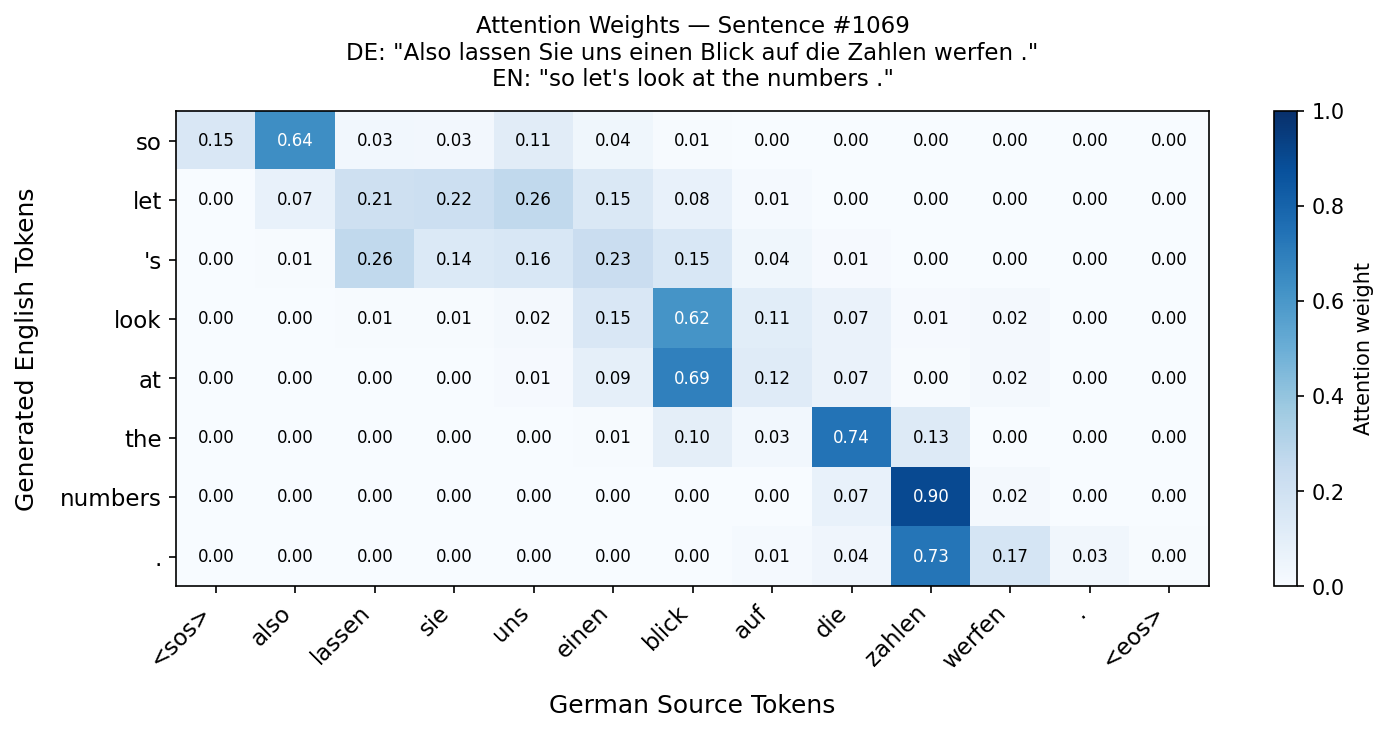


**Sentence #313** — *"Das ist etwas aus einem Roman ."* → *"this is something from a novel ."*

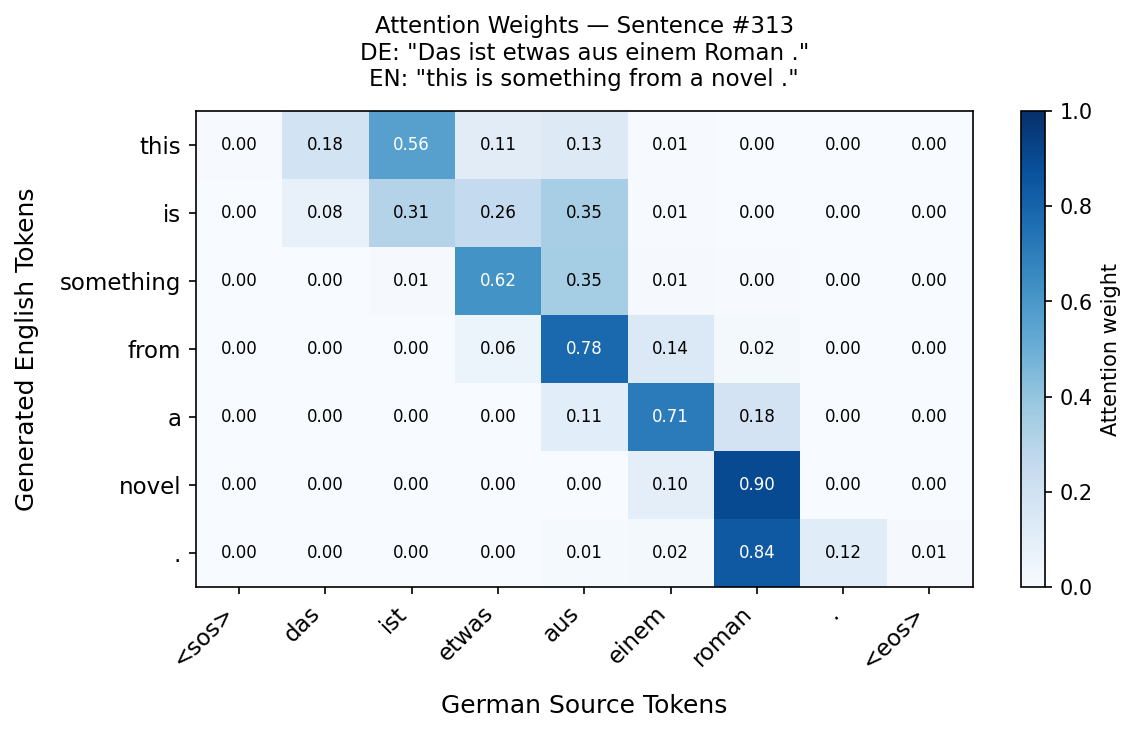


Both heatmaps show a clear **diagonal structure**, confirming that the fixed attention mechanism has learned meaningful German-English word alignments. Three patterns stand out across both sentences:

**1. Sharp lexical alignments.** Content words with direct one-to-one translations produce confident, near-exclusive peaks: *"zahlen"* → "numbers" (0.90), *"roman"* → "novel" (0.90), *"die"* → "the" (0.74), *"aus"* → "from" (0.78). In these cases the model has effectively learned a bilingual lexicon entry and uses it with high confidence.

**2. Diffuse alignments for grammatical / phrasal mappings.** The English phrase *"let 's"* maps to the German construction *"lassen … uns"* (positions 2 and 4), and the weights spread across positions 2–5 with no single dominant peak. Similarly, *"this is"* in sentence #313 spreads attention over *"das ist"* (positions 1–2). This is expected: when one target word corresponds to a multi-word source expression, the attention distributes rather than spikes.

## 4. Conclusion

We improved the seq2seq neural machine translation model through two techniques: implementing the additive attention mechanism and beam search decoding. The default model with broken attention achieves only 1.86 BLEU; our best model achieves 16.39 BLEU, an improvement of +14.53 points.

The most impactful improvement was **fixing the attention mechanism** (+12.38 BLEU), which allows the decoder to dynamically focus on relevant source words rather than using an uninformative average. **Beam search** contributed an additional +2.15 BLEU by exploring multiple translation candidates instead of committing to greedy choices.

## 5. References

- Bahdanau, D., Cho, K., & Bengio, Y. (2015). Neural Machine Translation by Jointly Learning to Align and Translate. ICLR 2015. arXiv:1409.0473.
- Sutskever, I., Vinyals, O., & Le, Q. V. (2014). Sequence to Sequence Learning with Neural Networks. NeurIPS 2014. arXiv:1409.3215.
- Luong, M. T., Pham, H., & Manning, C. D. (2015). Effective Approaches to Attention-based Neural Machine Translation. EMNLP 2015. arXiv:1508.04025.